In [53]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import re
from collections import Counter
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer

dataSet = pd.read_parquet(r"C:\Users\A.RUSSO\PycharmProjects\JupyterProject\data\ssh_attacks.parquet")

features = dataSet.columns

temporalColumns = dataSet["first_timestamp"]

dataSet['first_timestamp'] = pd.to_datetime(dataSet['first_timestamp'])


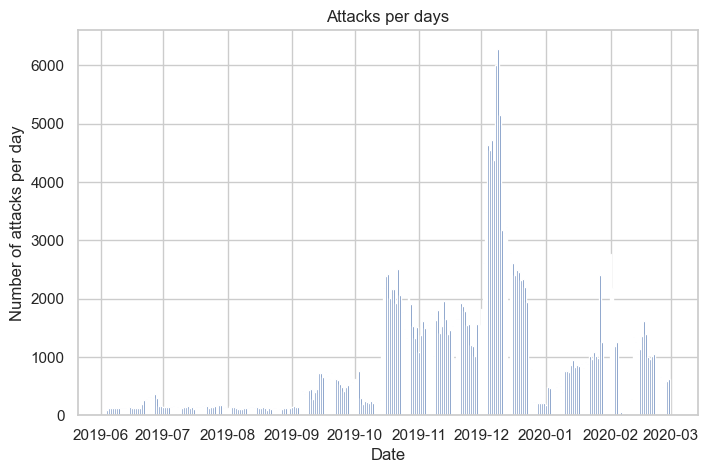

In [49]:

attacks_per_day = (
    dataSet.groupby(dataSet['first_timestamp'].dt.date)
           .size()
           .reset_index(name="number_of_attacks_per_day")
)

#-----------------------PLOT-----PER-NUMERO-ATTACCHI-------------------------------
plt.figure(figsize= (8,5))
plt.bar(attacks_per_day["first_timestamp"], attacks_per_day["number_of_attacks_per_day"])

plt.title("Attacks per days")
plt.xlabel("Date")
plt.ylabel("Number of attacks per day")
plt.show()
#------------------------------------------------------------------------------------





Codice per le distribuzioni di numero di caratteri per ogni sessione e numero di parole presenti per ogni sessione di attacco.

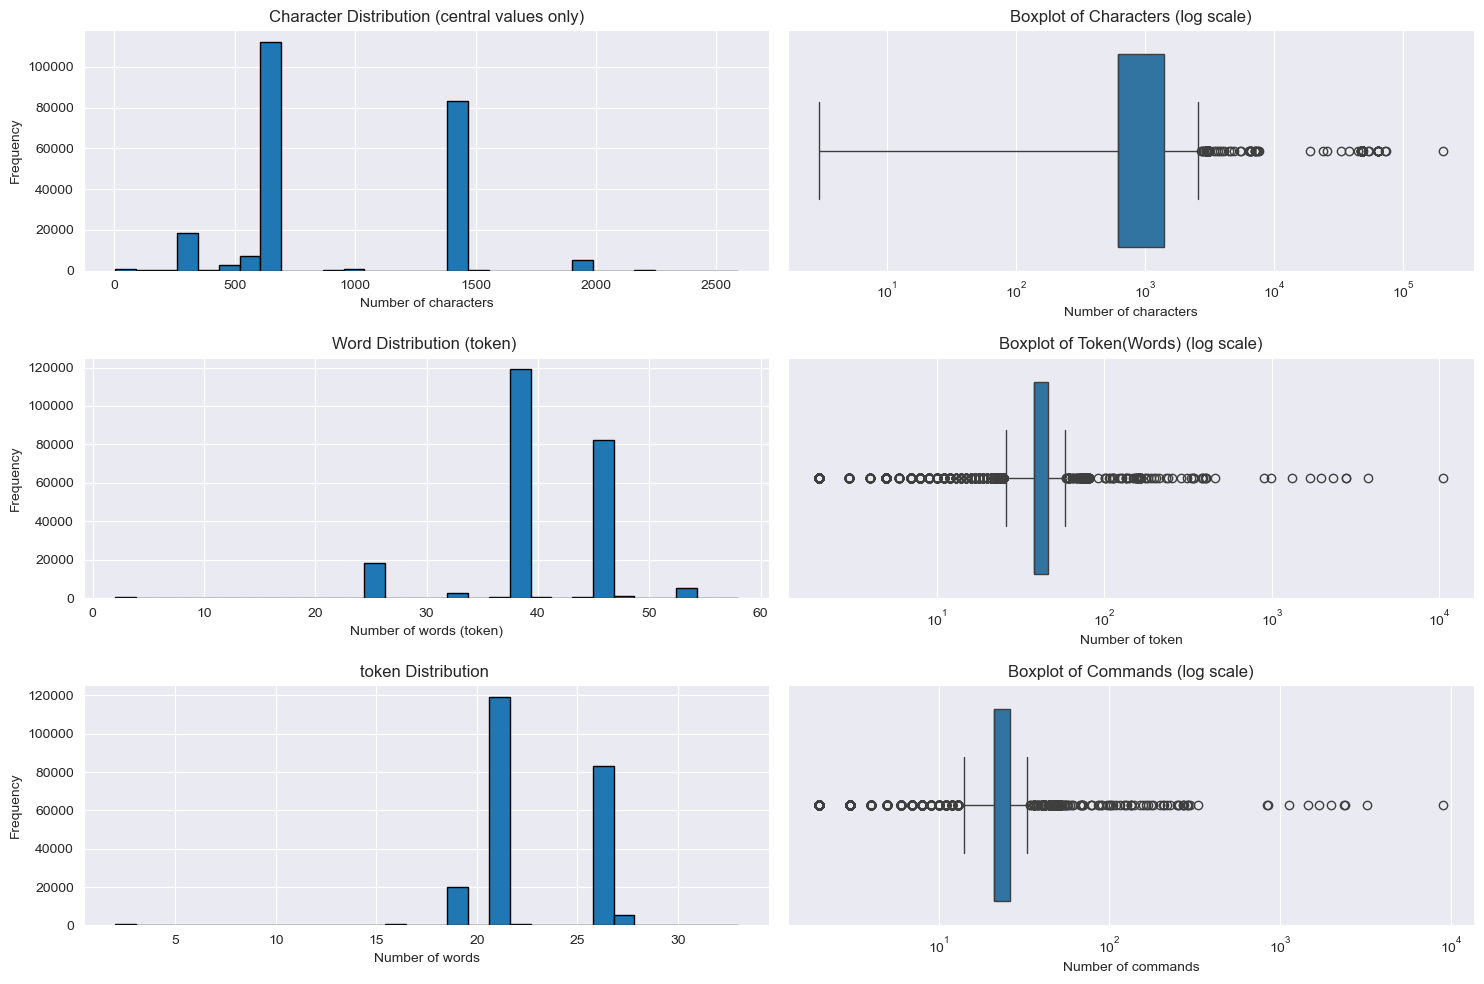

Max characters: 203442
Max words: 10471
Upper bound for outliers: 2616.5
Percentage of outliers: 0.3827751196172291 %


In [2]:
sessionCodeLen = dataSet[["full_session"]].copy()
sessionCodeLen["number_of_characters"] = sessionCodeLen["full_session"].str.len()

sessionWordsLen = dataSet[["full_session"]].copy()
sessionWordsLen["number_of_words_token"] = sessionWordsLen["full_session"].str.split(r";|\||&&|\|\||>>|>|<|&").str.len()

sessionWordsLen["number_of_words_command"] = sessionWordsLen["full_session"].str.split(r";").str.len()


# Calcolo outlier con metodo IQR
q1 = sessionCodeLen["number_of_characters"].quantile(0.25)
q3 = sessionCodeLen["number_of_characters"].quantile(0.75)
iqr = q3 - q1
upper_bound = q3 + 1.5 * iqr

q1_w = sessionWordsLen["number_of_words_token"].quantile(0.25)
q3_w = sessionWordsLen["number_of_words_token"].quantile(0.75)
iqr_w = q3_w - q1_w
upper_bound_w = q3_w + 1.5 * iqr_w

q1_w2 = sessionWordsLen["number_of_words_command"].quantile(0.25)
q3_w2 = sessionWordsLen["number_of_words_command"].quantile(0.75)
iqr_w2 = q3_w2 - q1_w2
upper_bound_w2 = q3_w2 + 1.5 * iqr_w2

central_chars = sessionCodeLen[sessionCodeLen["number_of_characters"] <= upper_bound]

central_words = sessionWordsLen[(sessionWordsLen["number_of_words_token"] <= upper_bound_w) & (sessionWordsLen["number_of_words_command"] <= upper_bound_w2)]


# === 2) Plotting =============================================

fig, axes = plt.subplots(3, 2, figsize=(15, 10))
sns.set(style="whitegrid")

# --- (A) Istogramma SENZA outlier -----------------------------
axes[0, 0].hist(central_chars["number_of_characters"], bins=30, edgecolor="black")
axes[0, 0].set_title("Character Distribution (central values only)")
axes[0, 0].set_xlabel("Number of characters")
axes[0, 0].set_ylabel("Frequency")


# --- (B) Boxplot completo con outlier -------------------------
sns.boxplot(x=sessionCodeLen["number_of_characters"], ax=axes[0, 1])
axes[0, 1].set_xscale("log")
axes[0, 1].set_title("Boxplot of Characters (log scale)")
axes[0, 1].set_xlabel("Number of characters")



# --- (C) Istogramma parole con eliminazione outlier ----------------------
axes[1, 0].hist(central_words["number_of_words_token"], bins=30, edgecolor="black")

axes[1, 0].set_title("Word Distribution (token) ")
axes[1, 0].set_xlabel("Number of words (token)")
axes[1, 0].set_ylabel("Frequency")


# --- (D) Boxplot completo con outlier in scala log -------------------------
sns.boxplot(x=sessionWordsLen["number_of_words_token"], ax=axes[1, 1])
axes[1, 1].set_xscale("log")
axes[1, 1].set_title("Boxplot of Token(Words) (log scale)")
axes[1, 1].set_xlabel("Number of token")

# --- (E) Istogramma parole con eliminazione outlier ----------------------
axes[2, 0].hist(central_words["number_of_words_command"], bins=30, edgecolor="black")

axes[2, 0].set_title("token Distribution ")
axes[2, 0].set_xlabel("Number of words")
axes[2, 0].set_ylabel("Frequency")

# --- (F) Istogramma parole con eliminazione outlier ----------------------
sns.boxplot(x=sessionWordsLen["number_of_words_command"], ax=axes[2, 1])
axes[2, 1].set_xscale("log")
axes[2, 1].set_title("Boxplot of Commands (log scale)")
axes[2, 1].set_xlabel("Number of commands")




plt.tight_layout()
plt.show()




# === 3) Statistiche utili =====================================

print("Max characters:", sessionCodeLen["number_of_characters"].max())
print("Max words:", sessionWordsLen["number_of_words_token"].max())
print("Upper bound for outliers:", upper_bound)
print("Percentage of outliers:",
      (1 - len(central_chars) / len(sessionCodeLen)) * 100, "%")

Codice per il punto 3 della sezione 1

In [3]:
sessionWordsLen["common_words_token"] = sessionWordsLen["full_session"].apply(
        lambda s: Counter([tok.strip()
              for cmd in re.split(r";|\||&&|\|\||>>|>|<|&", s)
              for tok in cmd.split()
              if tok.strip()]).most_common(1)[0][0] if isinstance(s, str) else None
)
sessionWordsLen["common_words_command"] = sessionWordsLen["full_session"].apply(
        lambda s: Counter([cmd.strip()
              for cmd in re.split(r";", s)
              if cmd.strip()]).most_common(1)[0][0] if isinstance(s, str) else None
)
print(sessionWordsLen)


#-----------------------------------stampa per i token----------------------------------
print(f"Questa è la parola in senso di token più comune tra i vari comandi di sessione: {sessionWordsLen["common_words_token"].value_counts().idxmax()}")


#----------------------------stampa per i comandi interi-------------------------------
print(f"Questa è la parola in senso di comandi più comune tra i vari comandi di sessione: {sessionWordsLen["common_words_command"].value_counts().idxmax()}")

                                             full_session  \
0       enable ; system ; shell ; sh ; cat /proc/mount...   
1       enable ; system ; shell ; sh ; cat /proc/mount...   
2       enable ; system ; shell ; sh ; cat /proc/mount...   
3       enable ; system ; shell ; sh ; cat /proc/mount...   
4       enable ; system ; shell ; sh ; cat /proc/mount...   
...                                                   ...   
233030  cat /proc/cpuinfo | grep name | wc -l ; echo -...   
233031  cat /proc/cpuinfo | grep name | wc -l ; echo -...   
233032  cat /proc/cpuinfo | grep name | wc -l ; echo -...   
233033  cat /proc/cpuinfo | grep name | wc -l ; echo -...   
233034  cat /proc/cpuinfo | grep name | wc -l ; echo -...   

        number_of_words_token  number_of_words_command common_words_token  \
0                          26                       19                 .s   
1                          26                       19                 .s   
2                          26       

Analisi delle distribuzioni

                                           L'intent più numeroso è Discovery                                            


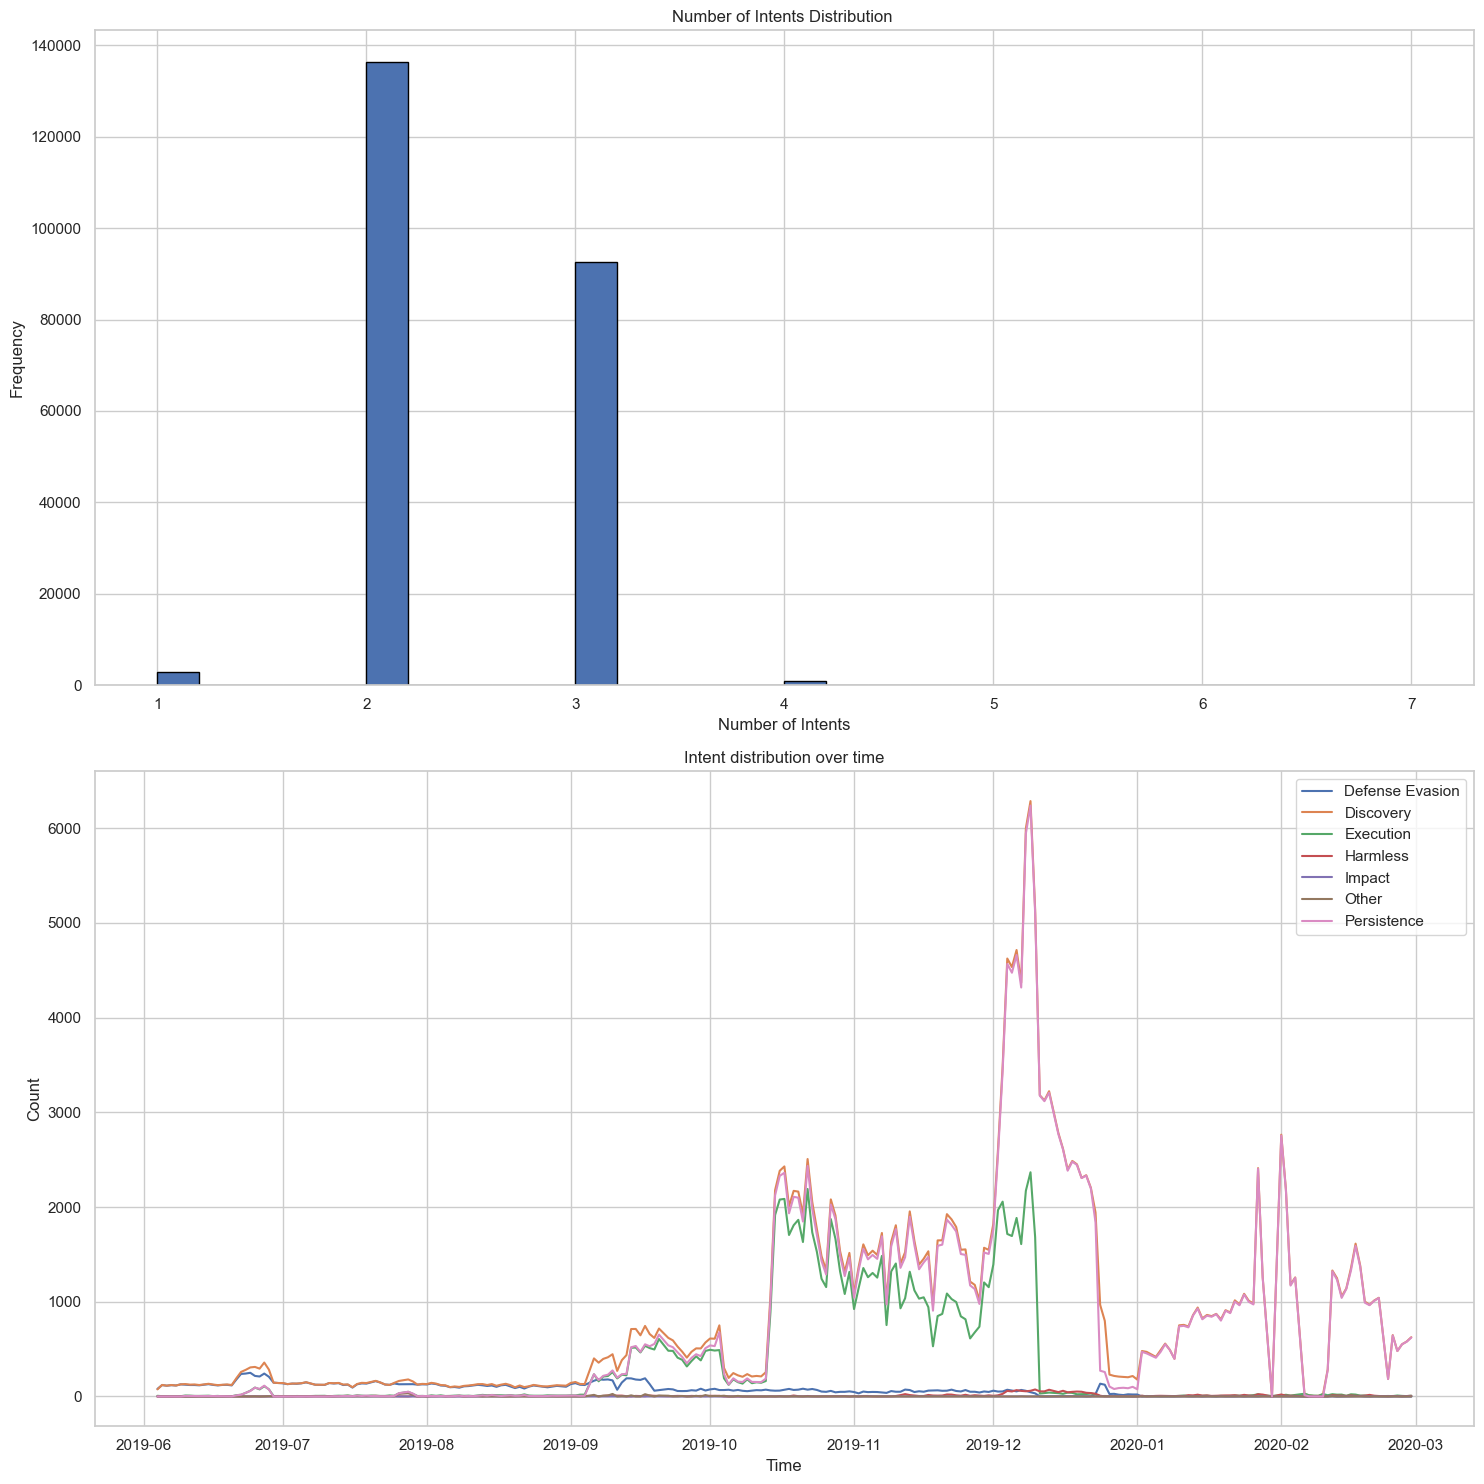

In [46]:
sessionIntents = dataSet[["Set_Fingerprint"]].copy()
sessionIntents["Time"] = dataSet["first_timestamp"]

#calcolo del common intent

exploded = sessionIntents.explode('Set_Fingerprint')

global_common = exploded['Set_Fingerprint'].value_counts().idxmax()

sessionIntents["numberOfIntentsPerSession"] = sessionIntents["Set_Fingerprint"].str.len()

#-----------------------------------------------------------------------------------------
fig, axes = plt.subplots(2, 1, figsize=(15, 15))


axes[0].hist(sessionIntents["numberOfIntentsPerSession"], bins=30, edgecolor="black")

axes[0].set_title("Number of Intents Distribution ")
axes[0].set_xlabel("Number of Intents")
axes[0].set_ylabel("Frequency")


#-----------------------------------------------------------------------------------------
groupIntents = sessionIntents.groupby("Set_Fingerprint")


#---------------------------------------------------------------------------------------------
print(f"{f"L'intent più numeroso è {global_common}":^120}")

#----------------------------------------ANALISI-TEMPORALE------------------------------------

exploded["day"] = exploded["Time"].dt.floor("D")
distribution_time = (
    exploded
    .groupby(["day", "Set_Fingerprint"])
    .size()
    .unstack(fill_value=0)
)




for intent in distribution_time.columns:
    plt.plot(distribution_time.index,
             distribution_time[intent],
             label=intent)

axes[1].set_title("Intent distribution over time")
axes[1].set_xlabel("Time")
axes[1].set_ylabel("Count")
axes[1].legend()
axes[1].grid(True)
plt.tight_layout()
plt.show()


Codice per le (BoW)

In [52]:
vectorizerBoW = CountVectorizer(token_pattern=r"[^\s]+")

X = vectorizerBoW.fit_transform(dataSet["full_session"])

print(X)

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 12104734 stored elements and shape (233035, 397636)>
  Coords	Values
  (0, 349614)	1
  (0, 336399)	18
  (0, 383542)	1
  (0, 380977)	1
  (0, 380773)	1
  (0, 343300)	3
  (0, 331990)	1
  (0, 331274)	4
  (0, 379384)	4
  (0, 343458)	1
  (0, 331300)	1
  (0, 331234)	5
  (0, 396949)	3
  (0, 345441)	1
  (0, 331276)	1
  (0, 384513)	1
  (0, 390564)	1
  (0, 346621)	1
  (0, 342455)	1
  (0, 345417)	1
  (0, 358006)	1
  (0, 390646)	1
  (0, 377370)	1
  (0, 357434)	1
  (0, 348133)	1
  :	:
  (233034, 351603)	1
  (233034, 330817)	2
  (233034, 365808)	1
  (233034, 330321)	1
  (233034, 330751)	1
  (233034, 330324)	1
  (233034, 330326)	1
  (233034, 330329)	1
  (233034, 330330)	1
  (233034, 330816)	1
  (233034, 330320)	1
  (233034, 364349)	1
  (233034, 345619)	1
  (233034, 389542)	1
  (233034, 366629)	2
  (233034, 385501)	1
  (233034, 364355)	1
  (233034, 330801)	1
  (233034, 372514)	2
  (233034, 332726)	1
  (233034, 41706)	1
  (233034, 332927)	1
  (

TF-IDF

In [58]:
vectorizerTF = TfidfVectorizer(token_pattern=r"[^\s]+")

X2 = vectorizerTF.fit_transform(dataSet["full_session"])

tokens = vectorizerTF.get_feature_names_out()

# X2 = matrice sparse TF-IDF
# row.data e row.indices valgono per riga, ma qui serve tutta la matrice

# convertiamo la matrice sparsa in formato COO (facile da manipolare)
X_coo = X2.tocoo()

# indici delle 5 voci più alte
top_idx = np.argsort(X_coo.data)[-5:][::-1]

for idx in top_idx:
    row_idx = X_coo.row[idx]
    col_idx = X_coo.col[idx]
    value = X_coo.data[idx]
    token = tokens[col_idx]
    print(f"Sessione {row_idx}, Token: {token}, TF-IDF: {value:.3f}")


Sessione 214532, Token: iconfig, TF-IDF: 0.997
Sessione 222688, Token: http://licart.ro/lucrare_concurs19.php?id=3146, TF-IDF: 0.997
Sessione 14264, Token: uptime, TF-IDF: 0.996
Sessione 224372, Token: help, TF-IDF: 0.995
Sessione 29086, Token: id, TF-IDF: 0.994
